In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

Inspection

In [19]:
housing_data = fetch_california_housing()
dataframe = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
dataframe["MedHouseVal"] = housing_data.target
dataframe.head()
dataframe.shape
dataframe.columns
dataframe.info()
dataframe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


DATA VISUALIZATION/ Exploratory Data Analysis

Understand evey feature


In [26]:
housing_data.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib:\nhttps://lib.stat.cmu.edu/datasets/houses.zip\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S. census, using one row per

In [ ]:
feature_descriptions = {
    "MedInc": "Median income in the block group",
    "HouseAge": "Median house age of the houses in the block group",
    "AveRooms": "Average rooms per household",
    "AveBedrms": "Average number of bedrooms per household",
    "Population": "Total population of the area",
    "AveOccup": "Average number of occupants per household",
    "Longitude": "Longitude coordinate of the area",
    "Latitude": "Latitude coordinate of the area",
    "MedHouseVal": "Median house value for California districts"
}
features = pd.DataFrame(feature_descriptions.items(), columns=["Feature", "Description"], index=range(1, len(feature_descriptions) + 1))
features

,Feature,Description
1,MedInc,Median income of the area
2,HouseAge,Average age of the houses in the area
3,AveRooms,Average number of rooms per house
4,AveBedrms,Average number of bedrooms per household
5,Population,Total population of the area
6,AveOccup,Average number of occupants per household
7,Longitude,Longitude coordinate of the area
8,Latitude,Latitude coordinate of the area
9,MedHouseVal,Median house value for California districts


Check missing values

In [39]:
dataframe.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

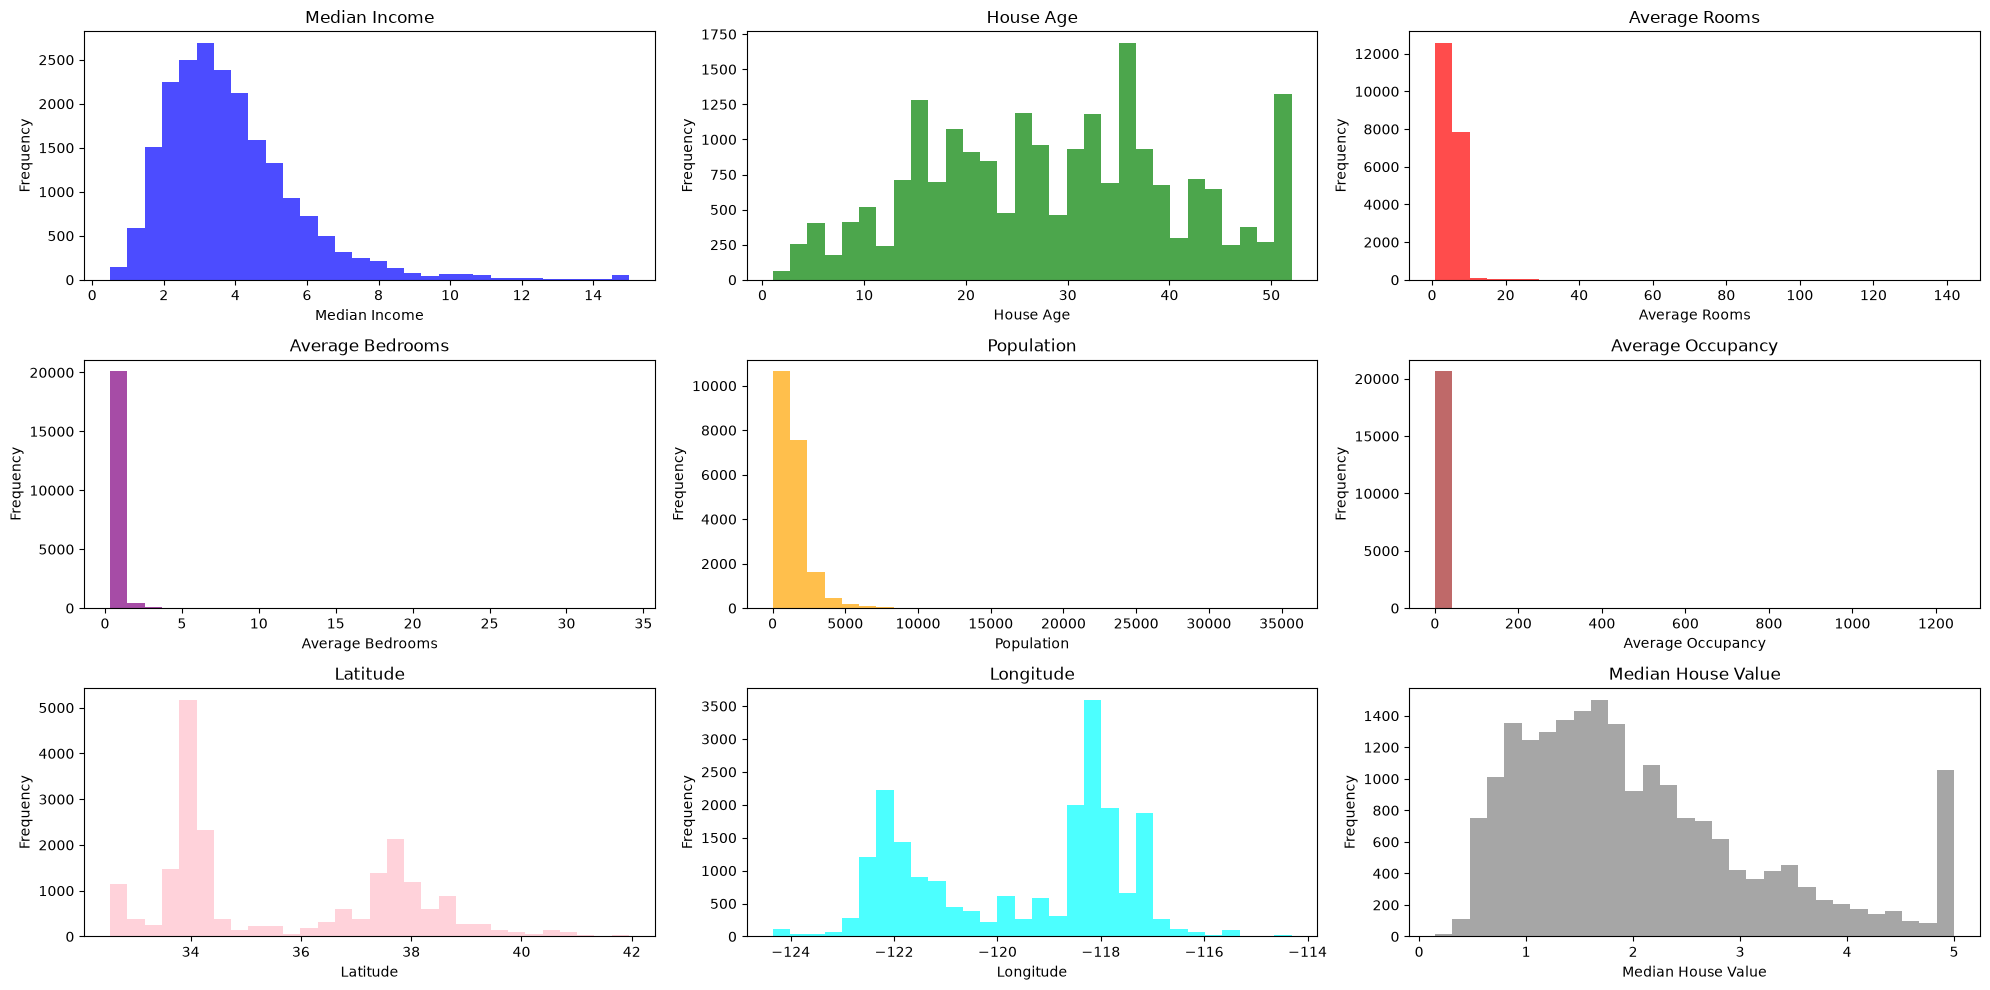

In [40]:
fig, axes = plt.subplots(3, 3, figsize=(20, 10))

axes[0, 0].hist(dataframe["MedInc"], bins=30, color='blue', alpha=0.7)
axes[0, 0].set_title("Median Income")
axes[0, 0].set_xlabel("Median Income")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(dataframe["HouseAge"], bins=30, color='green', alpha=0.7)
axes[0, 1].set_title("House Age")
axes[0, 1].set_xlabel("House Age")
axes[0, 1].set_ylabel("Frequency")

axes[0, 2].hist(dataframe["AveRooms"], bins=30, color='red', alpha=0.7)
axes[0, 2].set_title("Average Rooms")
axes[0, 2].set_xlabel("Average Rooms")
axes[0, 2].set_ylabel("Frequency")

axes[1, 0].hist(dataframe["AveBedrms"], bins=30, color='purple', alpha=0.7)
axes[1, 0].set_title("Average Bedrooms")
axes[1, 0].set_xlabel("Average Bedrooms")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(dataframe["Population"], bins=30, color='orange', alpha=0.7)
axes[1, 1].set_title("Population")
axes[1, 1].set_xlabel("Population")
axes[1, 1].set_ylabel("Frequency")

axes[1, 2].hist(dataframe["AveOccup"], bins=30, color='brown', alpha=0.7)
axes[1, 2].set_title("Average Occupancy")
axes[1, 2].set_xlabel("Average Occupancy")
axes[1, 2].set_ylabel("Frequency")

axes[2, 0].hist(dataframe["Latitude"], bins=30, color='pink', alpha=0.7)
axes[2, 0].set_title("Latitude")
axes[2, 0].set_xlabel("Latitude")
axes[2, 0].set_ylabel("Frequency")

axes[2, 1].hist(dataframe["Longitude"], bins=30, color='cyan', alpha=0.7)
axes[2, 1].set_title("Longitude")
axes[2, 1].set_xlabel("Longitude")
axes[2, 1].set_ylabel("Frequency")

axes[2, 2].hist(dataframe["MedHouseVal"], bins=30, color='gray', alpha=0.7)
axes[2, 2].set_title("Median House Value")
axes[2, 2].set_xlabel("Median House Value")
axes[2, 2].set_ylabel("Frequency")

plt.tight_layout()


Visulize target separately


In [48]:
min_value = dataframe["MedHouseVal"].min()
min_value

np.float64(0.14999)

In [47]:
max_value = dataframe["MedHouseVal"].max()
max_value

np.float64(5.00001)

In [49]:
mean_value = dataframe["MedHouseVal"].mean()
mean_value

np.float64(2.0685581690891475)

In [50]:
median_value = dataframe["MedHouseVal"].median()
median_value

np.float64(1.797)

(array([ 877., 3612., 4099., 3771., 2799., 1769., 1239.,  752.,  479.,
        1243.]),
 array([0.14999 , 0.634992, 1.119994, 1.604996, 2.089998, 2.575   ,
        3.060002, 3.545004, 4.030006, 4.515008, 5.00001 ]),
 <BarContainer object of 10 artists>)

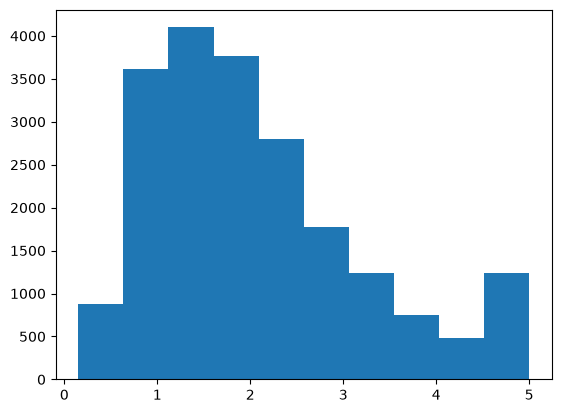

In [56]:
plt.hist(dataframe["MedHouseVal"])

Relationship between target and feature
#Correlation matrix


In [58]:
corr_matrix = dataframe.corr()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

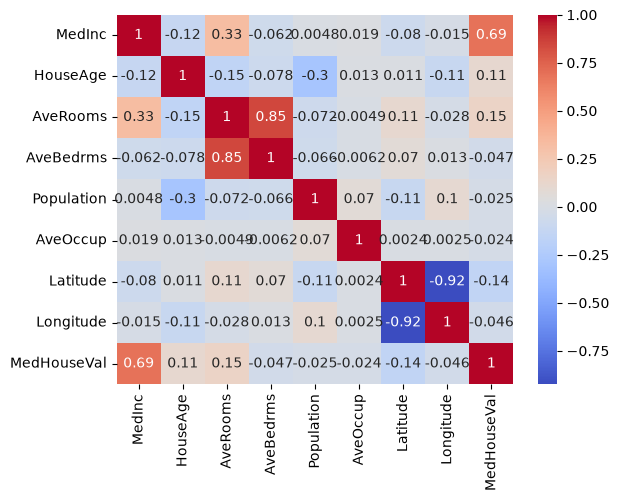

In [68]:
#Create heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

MedInc shows the greatest correlation with the target 

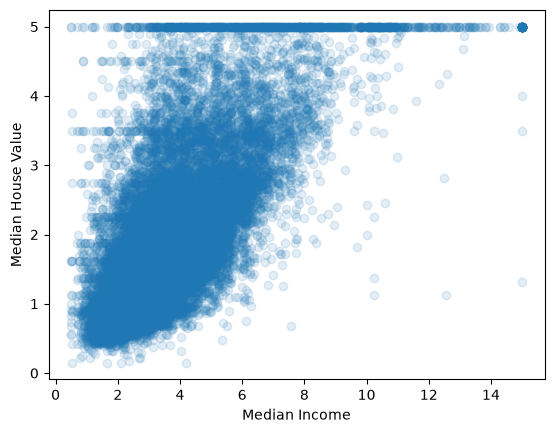

In [62]:
plt.scatter(dataframe["MedInc"], dataframe["MedHouseVal"], alpha=0.13)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

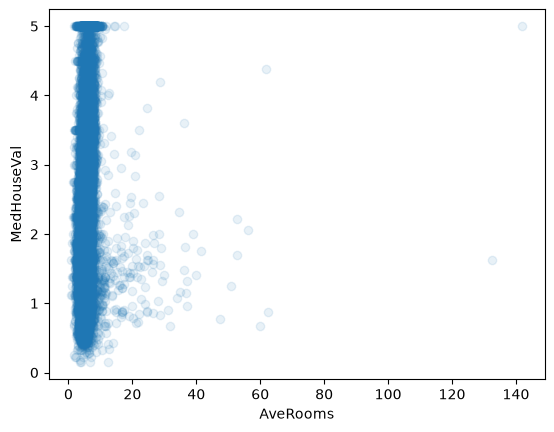

In [ ]:
#AveRooms vs MedHouseVal Scatterplot
plt.scatter(dataframe["AveRooms"], dataframe["MedHouseVal"], alpha=0.1)
plt.xlabel("AveRooms")
plt.ylabel("MedHouseVal")
plt.show()

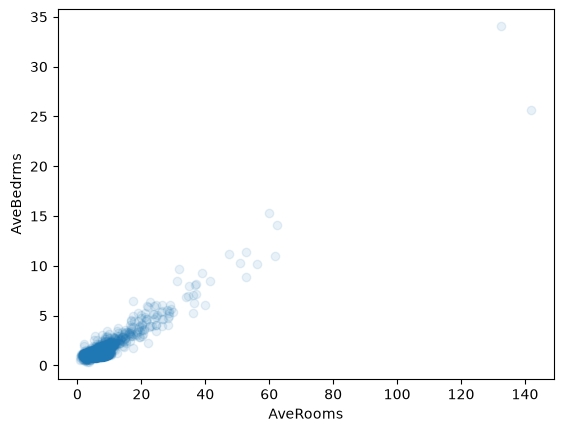

In [72]:
#AveRooms vs AveBedrms Scatterplot
plt.scatter(dataframe["AveRooms"], dataframe["AveBedrms"], alpha=0.1)
plt.xlabel("AveRooms")
plt.ylabel("AveBedrms")
plt.show()

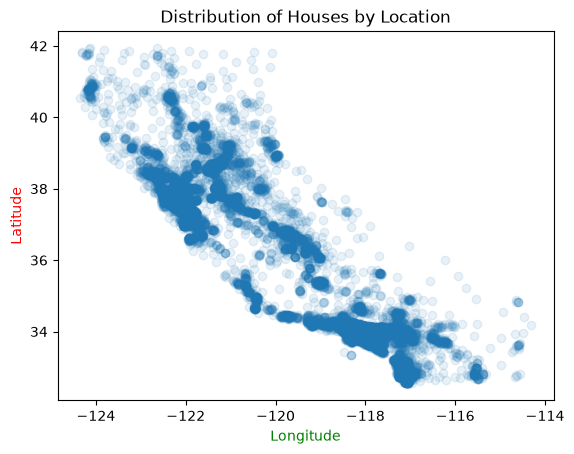

In [23]:
#Scatter plot of longitude and latitude
plt.scatter(dataframe["Longitude"], dataframe["Latitude"], alpha=0.1)
plt.xlabel("Longitude", color='green')
plt.ylabel("Latitude", color='red')
plt.title("Distribution of Houses by Location")
plt.show()

Remember to include observation and hypothesis

DAta Prep

In [75]:
#Separate the features and target variable
X = dataframe.drop("MedHouseVal", axis=1)
y = dataframe["MedHouseVal"]



In [76]:
#Verify the shapes of the features and target variable
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [77]:
#Check for missing values in the features and target variable
print("Missing values in features:\n", X.isnull().sum())
print("Missing values in target:\n", y.isnull().sum())

Missing values in features:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Missing values in target:
 0


In [78]:
#Check for duplicates in the features and target variable
print("Duplicate rows in features:", X.duplicated().sum())
print("Duplicate rows in target:", y.duplicated().sum())

Duplicate rows in features: 0
Duplicate rows in target: 16798


In [80]:
#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Verify the splits
print("Training features shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nTesting features shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (16512, 8)
Training target shape: (16512,)

Testing features shape: (4128, 8)
Testing target shape: (16512,)


In [ ]:
#Linear Regression Implementation using gradientdescent
def Linear_Regression(X, y, eta=0.1, epochs=1000):
    n_of_samples, n_of_features = X.shape
    theta_0 = 0
    theta = np.zeros(n_of_features)

    for epoch in range(epochs):
        for i in range(n_of_samples):
            x_i = X[i]
            y_i = y[i]

            #Calulate predictions
            predictions = np.dot(x_i, theta) + theta_0

            #Calculate errors
            error = y_i - predictions
            actual_error = error **2

            #Implement gradient descent
            weights = 2 * np.dot(x_i, error)
            intercept = 2 * error

            #Update parameters
            theta = theta - (eta * weights)
            theta_0 = theta_0 - (eta * intercept)
            
    return theta, theta_0        


    